In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')


df_kf = pd.read_csv('results/kalman_dynamic_spreads.csv')
print("Columns:", df_kf.columns.tolist())
df_clean = df_kf.dropna(subset=['spread_kf', 'beta_kf', 'alpha_kf'])


df_clean['pair'] = df_clean['stock1'] + '_' + df_clean['stock2']
df_clean['date'] = pd.to_datetime(df_clean['date'])

print(f"Raw: {len(df_kf):,} → Clean: {len(df_clean):,} rows")
print(f"{df_clean['pair'].nunique()} unique pairs ready")
print("\nTop 5 pairs by data points:")
print(df_clean.groupby('pair').size().nlargest(5))
df_clean.head()




Columns: ['stock1', 'stock2', 'date', 'beta_kf', 'alpha_kf', 'P_beta', 'spread_kf', 'stability']
Raw: 60,847 → Clean: 58,567 rows
19 unique pairs ready

Top 5 pairs by data points:
pair
CRM_CI       3968
HON_SHW      3968
HON_SYK      3968
INTU_MRSH    3968
LIN_QCOM     3968
dtype: int64


,stock1,stock2,date,beta_kf,alpha_kf,P_beta,spread_kf,stability,pair
120,MA,UBER,2019-10-30,0.126099,5.133817,0.021691,0.011809,0.24,MA_UBER
121,MA,UBER,2019-10-31,0.125789,5.137012,0.021699,0.017154,0.24,MA_UBER
122,MA,UBER,2019-11-01,0.125288,5.141582,0.021705,0.022892,0.24,MA_UBER
123,MA,UBER,2019-11-04,0.124816,5.144785,0.021703,0.012681,0.24,MA_UBER
124,MA,UBER,2019-11-05,0.125110,5.143634,0.021126,-0.001097,0.24,MA_UBER


In [2]:
def fit_hmm_regimes(spreads, n_states=4, min_length=100):
    """Fit 4-state HMM to ANY spread series"""
    if len(spreads) < min_length:
        return None, None, None
    
    
    scaler = StandardScaler()
    spreads_scaled = scaler.fit_transform(spreads.reshape(-1, 1)).flatten()
    
   
    model = hmm.GaussianHMM(
        n_components=n_states, 
        covariance_type="full", 
        n_iter=100, 
        random_state=42
    )
    model.fit(spreads_scaled.reshape(-1, 1))
    
    regimes = model.predict(spreads_scaled.reshape(-1, 1))
    probs = model.predict_proba(spreads_scaled.reshape(-1, 1))
    
    return model, regimes, probs

print("HMM engine ready (4 regimes per pair)")


HMM engine ready (4 regimes per pair)


In [3]:

all_pairs = sorted(df_clean['pair'].unique())
print(f"Processing ALL {len(all_pairs)} pairs from your screening...")

regime_results = {}
for i, pair in enumerate(all_pairs, 1):
   
    pair_data = df_clean[df_clean['pair'] == pair].sort_values('date')
    spreads = pair_data['spread_kf'].values
    
    print(f"  {i:2d}/{len(all_pairs)} {pair:10s} ({len(spreads):4d} days)", end=' ')
    
    model, regimes, probs = fit_hmm_regimes(spreads)
    if model is not None:
        regime_results[pair] = {
            'model': model, 
            'regimes': regimes, 
            'probs': probs,
            'dates': pair_data['date'].values,
            'spreads': spreads
        }
        print(f"{len(regimes)} regimes")
    else:
        print("skipped (too short)")

print(f"\nCOMPLETE: {len(regime_results)}/{len(all_pairs)} pairs processed!")






Processing ALL 19 pairs from your screening...
   1/19 ABNB_APD   (1214 days) 1214 regimes
   2/19 AMZN_DASH  (1215 days) 1215 regimes
   3/19 APP_COF    (1129 days) 1129 regimes
   4/19 CRM_CI     (3968 days) 3968 regimes
   5/19 HON_SHW    (3968 days) 3968 regimes
   6/19 HON_SYK    (3968 days) 3968 regimes
   7/19 INTU_MRSH  (3968 days) 3968 regimes
   8/19 JPM_ANET   (2855 days) 2855 regimes
   9/19 LIN_QCOM   (3968 days) 3968 regimes
  10/19 MA_NSC     (3968 days) 3968 regimes
  11/19 MA_UBER    (1615 days) 1615 regimes
  12/19 MCK_DELL   (2301 days) 2301 regimes
  13/19 MRK_UNP    (3968 days) 3968 regimes
  14/19 NEE_TMO    (3968 days) 3968 regimes
  15/19 SCHW_HLT   (2975 days) 2975 regimes
  16/19 SYK_INTU   (3968 days) 3968 regimes
  17/19 TMO_HON    (3968 days) 3968 regimes
  18/19 TXN_SPGI   (3968 days) 3968 regimes
  19/19 UBER_ECL   (1615 days) 1615 regimes

COMPLETE: 19/19 pairs processed!


In [4]:

results_list = []
for pair, data in regime_results.items():
    for date, regime, probs, spread in zip(data['dates'], data['regimes'], data['probs'], data['spreads']):
        results_list.append({
            'pair': pair,
            'date': date,
            'regime': regime,
            'max_prob': np.max(probs),
            'spread': spread,
            'spread_z': (spread - np.mean(data['spreads'])) / np.std(data['spreads'])
        })

results_df = pd.DataFrame(results_list)
results_df.to_csv('results/hmm_regimes_ALL_pairs.csv', index=False)
print(f"Saved {len(results_df):,} rows → hmm_regimes_ALL_pairs.csv")
print("\nTrading columns:")
print(results_df[['pair', 'date', 'regime', 'spread_z', 'max_prob']].head())






Saved 58,567 rows → hmm_regimes_ALL_pairs.csv

Trading columns:
       pair       date  regime  spread_z  max_prob
0  ABNB_APD 2021-06-04       3  0.295344  1.000000
1  ABNB_APD 2021-06-07       3  0.161162  0.979383
2  ABNB_APD 2021-06-08       3 -0.004298  0.889049
3  ABNB_APD 2021-06-09       3 -0.178483  0.795619
4  ABNB_APD 2021-06-10       3 -0.055750  0.858412


Plotting 19 pairs: ['ABNB_APD', 'AMZN_DASH', 'APP_COF', 'CRM_CI', 'HON_SHW', 'HON_SYK', 'INTU_MRSH', 'JPM_ANET', 'LIN_QCOM', 'MA_NSC', 'MA_UBER', 'MCK_DELL', 'MRK_UNP', 'NEE_TMO', 'SCHW_HLT', 'SYK_INTU', 'TMO_HON', 'TXN_SPGI', 'UBER_ECL']


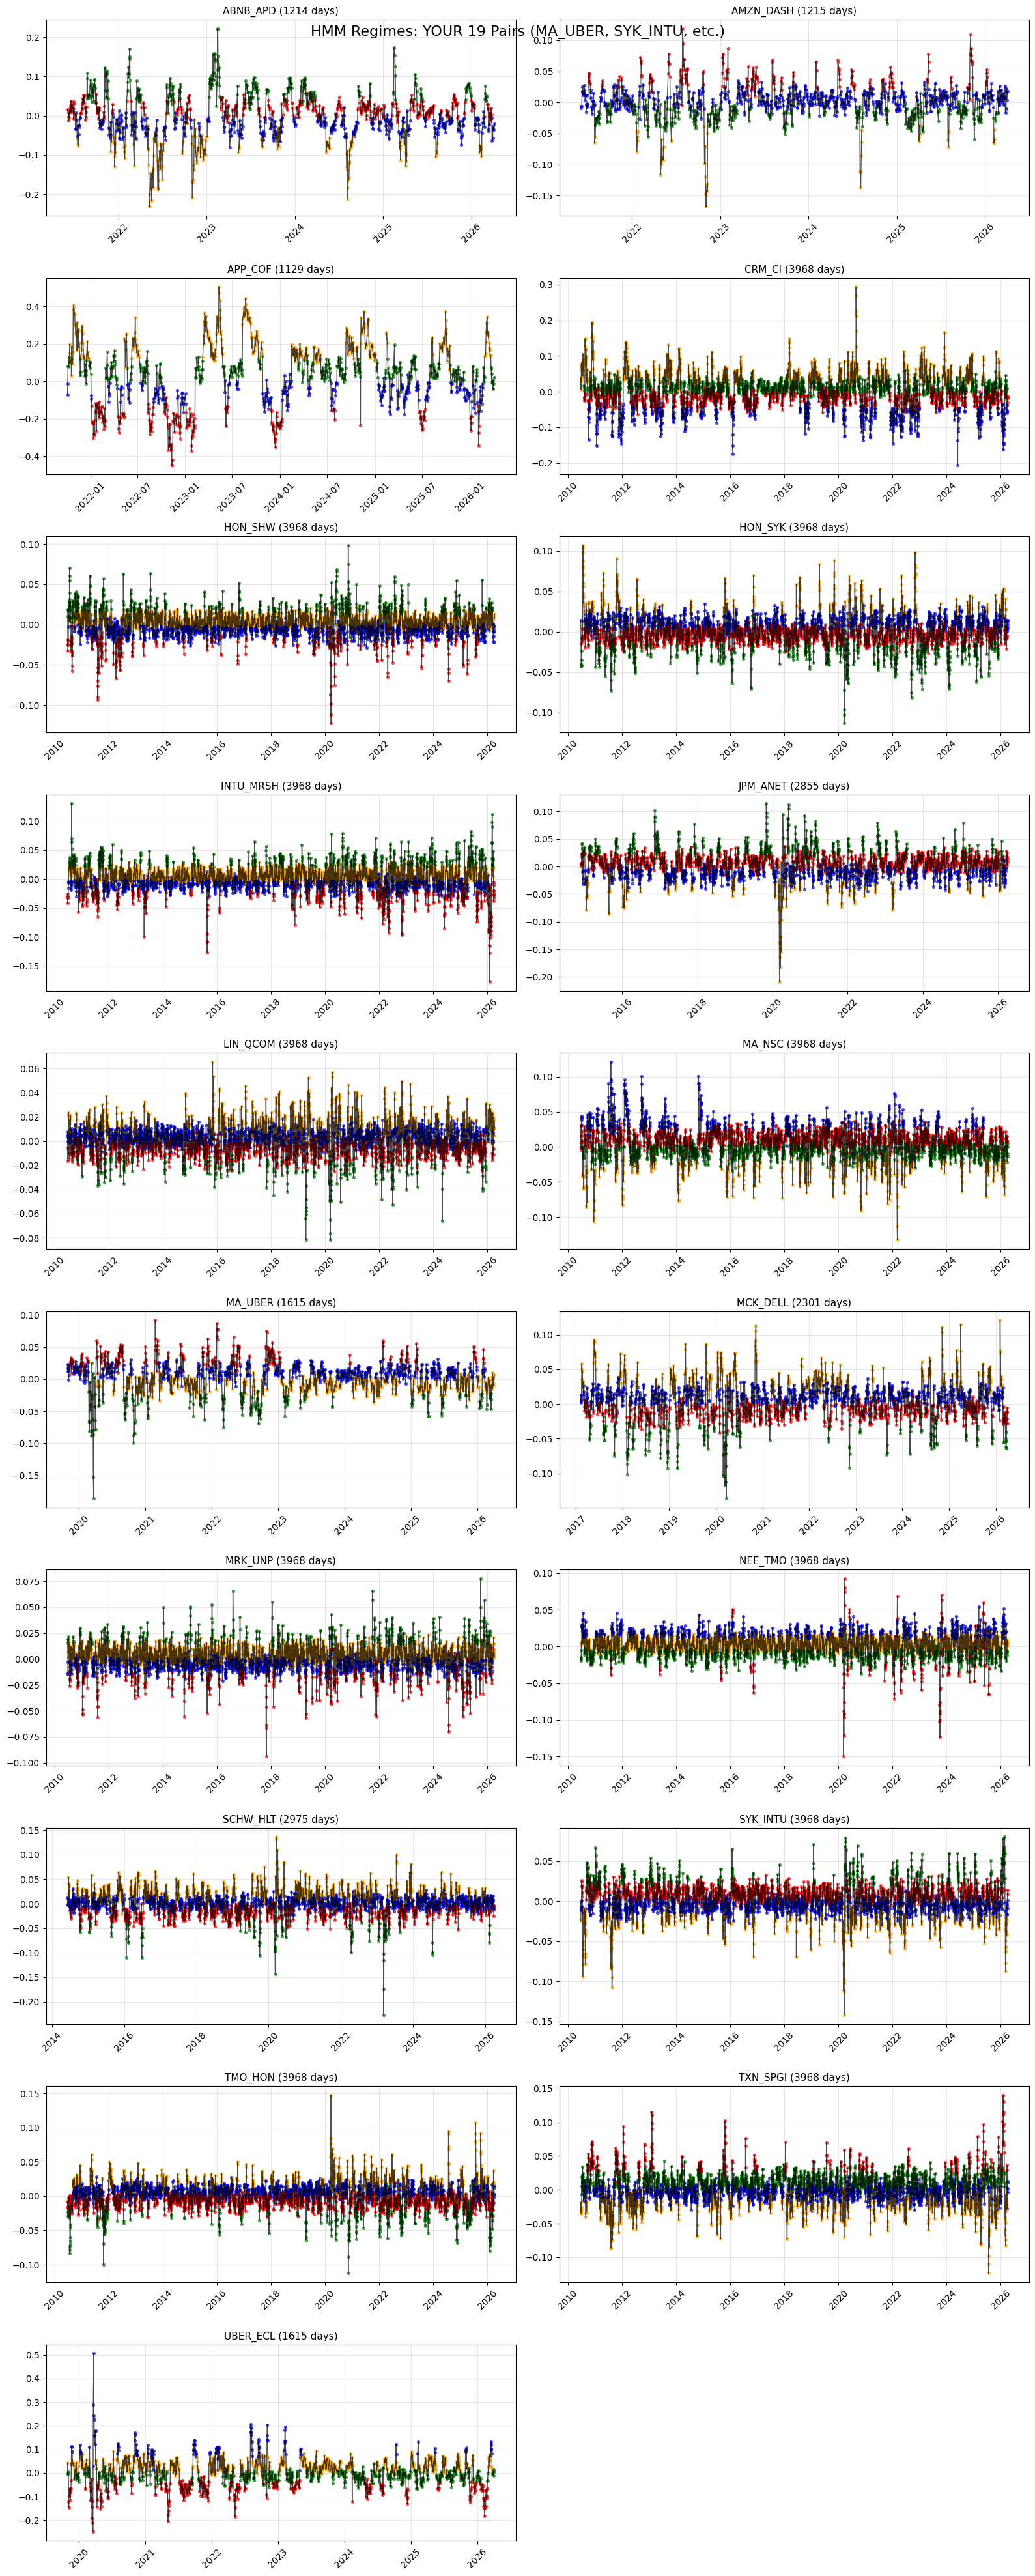

In [5]:

pairs_to_plot = list(regime_results.keys())  # ALL your pairs
n_pairs = len(pairs_to_plot)
n_rows = (n_pairs + 1) // 2  # 2 columns, auto rows
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4*n_rows))
if n_rows == 1: 
    axes = axes.reshape(1, -1)  # Handle single row

axes = axes.flatten()

print(f"Plotting {n_pairs} pairs: {pairs_to_plot}")

for idx, pair in enumerate(pairs_to_plot):
    data = regime_results[pair]
    
  
    axes[idx].plot(data['dates'], data['spreads'], 'k-', lw=1, alpha=0.7, label='Spread')
    colors = ['blue', 'green', 'orange', 'red']
    for state in range(4):
        mask = data['regimes'] == state
        axes[idx].scatter(data['dates'][mask], data['spreads'][mask], 
                         c=colors[state], s=8, alpha=0.6, label=f'St{state}')
    
    axes[idx].set_title(f'{pair} ({len(data["regimes"])} days)', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)


for idx in range(n_pairs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'HMM Regimes: YOUR {n_pairs} Pairs (MA_UBER, SYK_INTU, etc.)', fontsize=16)
plt.tight_layout()
plt.show()




In [6]:
# Show regime distribution across ALL pairs
regime_stats = []
for pair, data in regime_results.items():
    dist = pd.Series(data['regimes']).value_counts(normalize=True).sort_index()
    regime_stats.append({
        'pair': pair,
        'days': len(data['regimes']),
        'regime_0': dist.get(0, 0),
        'regime_1': dist.get(1, 0), 
        'regime_2': dist.get(2, 0),
        'regime_3': dist.get(3, 0),
        'avg_conf': np.mean(np.max(data['probs'], axis=1))
    })

stats_df = pd.DataFrame(regime_stats)
print("Regime Distribution Across ALL Pairs:")
print(stats_df.round(3).sort_values('days', ascending=False))
stats_df.to_csv('results/hmm_regime_stats.csv', index=False)



Regime Distribution Across ALL Pairs:
         pair  days  regime_0  regime_1  regime_2  regime_3  avg_conf
9      MA_NSC  3968     0.161     0.355     0.120     0.364     0.899
17   TXN_SPGI  3968     0.402     0.320     0.198     0.080     0.894
3      CRM_CI  3968     0.169     0.363     0.219     0.249     0.915
4     HON_SHW  3968     0.383     0.151     0.377     0.088     0.880
5     HON_SYK  3968     0.323     0.163     0.088     0.427     0.905
6   INTU_MRSH  3968     0.325     0.143     0.401     0.130     0.887
8    LIN_QCOM  3968     0.443     0.072     0.191     0.293     0.859
16    TMO_HON  3968     0.414     0.091     0.149     0.346     0.889
15   SYK_INTU  3968     0.402     0.105     0.130     0.362     0.900
12    MRK_UNP  3968     0.389     0.106     0.401     0.104     0.864
13    NEE_TMO  3968     0.208     0.312     0.437     0.044     0.883
14   SCHW_HLT  2975     0.485     0.043     0.238     0.235     0.899
7    JPM_ANET  2855     0.321     0.153     0.077   